In [132]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("API_URL"))
print(os.getenv("DATE_BEGIN"))
print(os.getenv("DATE_END"))

https://data-charts-api.hexlet.app
2023-03-01
2023-09-01


# Создаём переменные в коде

In [133]:
API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

Получим визиты:

In [134]:
url_visits = f"{API_URL}/visits"

response = requests.get(
    url_visits,
    params={
        "begin": DATE_BEGIN,
        "end": DATE_END
    }
)

visits = pd.DataFrame(response.json())

Получим регистрации:

In [135]:
url_registrations = f"{API_URL}/registrations"

response = requests.get(
    url_registrations,
    params={
        "begin": DATE_BEGIN,
        "end": DATE_END
    }
)

registrations = pd.DataFrame(response.json())

In [136]:
registrations.head()

,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google


Убрать ботов:

In [137]:
visits = visits[~visits['user_agent'].str.lower().str.contains('bot')]

Берём только последний визит пользователя

Преобразуем дату:

In [138]:
visits['datetime'] = pd.to_datetime(visits['datetime'])

Отсортируем:

In [139]:
visits = visits.sort_values('datetime')

Оставляем последний визит:

In [140]:
visits = visits.drop_duplicates(
    subset='visit_id',
    keep='last'
)

Получим дату для группировки

In [141]:
visits['date_group'] = visits['datetime'].dt.date

In [142]:
registrations['datetime'] = pd.to_datetime(registrations['datetime'])

registrations['date_group'] = registrations['datetime'].dt.date

Группируем визиты

In [143]:
visits_grouped = (
    visits
    .groupby(['date_group', 'platform'])
    .agg(visits=('visit_id', 'count'))
    .reset_index()
)

Группируем регистрации

In [144]:
registrations_grouped = (
    registrations
    .groupby(['date_group', 'platform'])
    .agg(registrations=('user_id', 'count'))
    .reset_index()
)

Объединяем таблицы

In [145]:
conversion = visits_grouped.merge(
    registrations_grouped,
    on=['date_group', 'platform'],
    how='left'
)

Заполняем пропуски

In [146]:
conversion['registrations'] = conversion['registrations'].fillna(0)

Считаем конверсию

In [147]:
conversion['conversion'] = (
    conversion['registrations'] /
    conversion['visits']
) * 100

Сортируем по дате

In [148]:
conversion = conversion.sort_values('date_group')

In [149]:
conversion.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355


Сгруппируем данные по конверсиям по дате

In [150]:
conversion_grouped = (
    conversion
    .groupby(['date_group'])
    .agg(visits = ('visits', 'sum'),
        registrations=('registrations', 'sum'))
    .reset_index()
)

In [151]:
conversion_grouped.head()

,date_group,visits,registrations
0,2023-03-01,376,87
1,2023-03-02,613,106
2,2023-03-03,683,107
3,2023-03-04,647,159
4,2023-03-05,707,115


Получим данные о рекламе

In [152]:
ads_table = pd.read_csv('./ads.csv')

Преобразуем даты

In [153]:
ads_table['date'] = pd.to_datetime(ads_table['date'])

In [154]:
ads_table['date_group'] = ads_table['date'].dt.date

Сгруппируем данные по рекламе

In [155]:
ads_grouped = (
    ads_table
    .groupby(['date_group', 'utm_campaign'])
    .agg(cost = ('cost', 'sum'))
    .reset_index()
)

Объединим таблицы

In [156]:
ads = conversion_grouped.merge (
    ads_grouped,
    on = 'date_group',
    how = 'left') 

In [157]:

ads = ads[['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']] 

Заполним пропуски

In [158]:
ads['cost'] = ads['cost'].fillna(0)
ads['utm_campaign'] = ads['utm_campaign'].fillna('none')

Отсортируем данные по дате

In [159]:
ads = ads.sort_values('date_group')

In [160]:
ads.head()

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,212.0,advanced_algorithms_series
1,2023-03-02,613,106,252.0,advanced_algorithms_series
2,2023-03-03,683,107,202.0,advanced_algorithms_series
3,2023-03-04,647,159,223.0,advanced_algorithms_series
4,2023-03-05,707,115,265.0,advanced_algorithms_series


Выберем период

In [161]:
conversion_grouped["date_group"] = pd.to_datetime(conversion_grouped["date_group"])

In [162]:
conversion_period = conversion_grouped[
    (conversion_grouped["date_group"] >= DATE_BEGIN) &
    (conversion_grouped["date_group"] < DATE_END)
]

In [163]:
conversion_period

,date_group,visits,registrations
0,2023-03-01,376,87
1,2023-03-02,613,106
2,2023-03-03,683,107
3,2023-03-04,647,159
4,2023-03-05,707,115
...,...,...,...
179,2023-08-27,795,88
180,2023-08-28,635,83
181,2023-08-29,1268,143
182,2023-08-30,1328,101


# Итоговые визиты

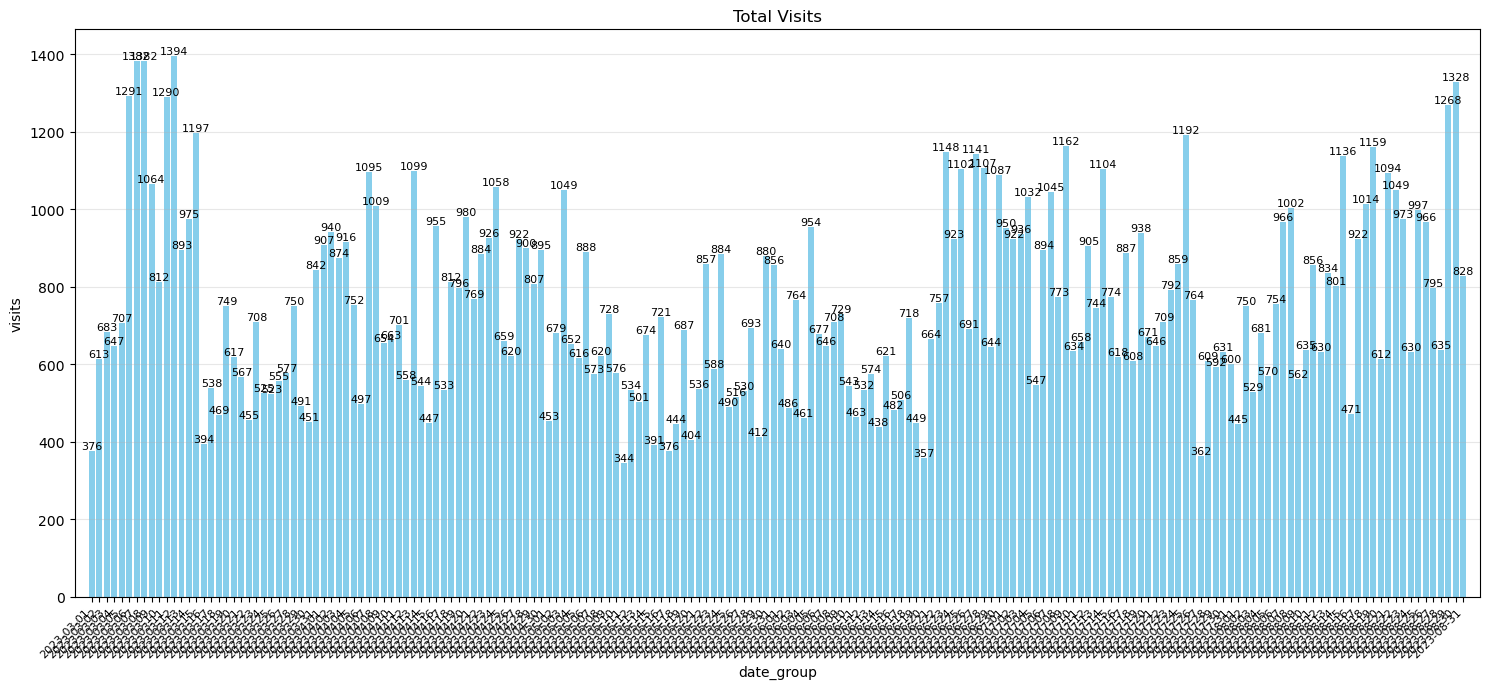

In [164]:
plt.figure(figsize=(15, 7))

bars = plt.bar(
    conversion_period["date_group"].dt.strftime("%Y-%m-%d"),
    conversion_period["visits"],
    color="skyblue",
    width=0.8
)

plt.bar_label(bars, fontsize=8)
plt.title("Total Visits")
plt.xlabel("date_group")
plt.ylabel("visits")

plt.xticks(rotation=45, ha="right", fontsize=8)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.margins(x=0.01)

plt.savefig('./charts/Total Visits.png')

plt.show()

# Итоговые визиты с разбивкой по платформам

In [165]:
conversion["date_group"] = pd.to_datetime(conversion["date_group"])
conversion_period_by_platforms = conversion[
    (conversion["date_group"] >= DATE_BEGIN) &
    (conversion["date_group"] < DATE_END)
]

In [166]:
pivot = conversion_period_by_platforms.pivot(
    index="date_group",
    columns="platform",
    values="visits")

In [167]:
pivot

platform,android,ios,web
date_group,,,
2023-03-01,75,22,279
2023-03-02,67,31,515
2023-03-03,26,40,617
2023-03-04,94,68,485
2023-03-05,66,16,625
...,...,...,...
2023-08-27,56,24,715
2023-08-28,44,35,556
2023-08-29,71,28,1169


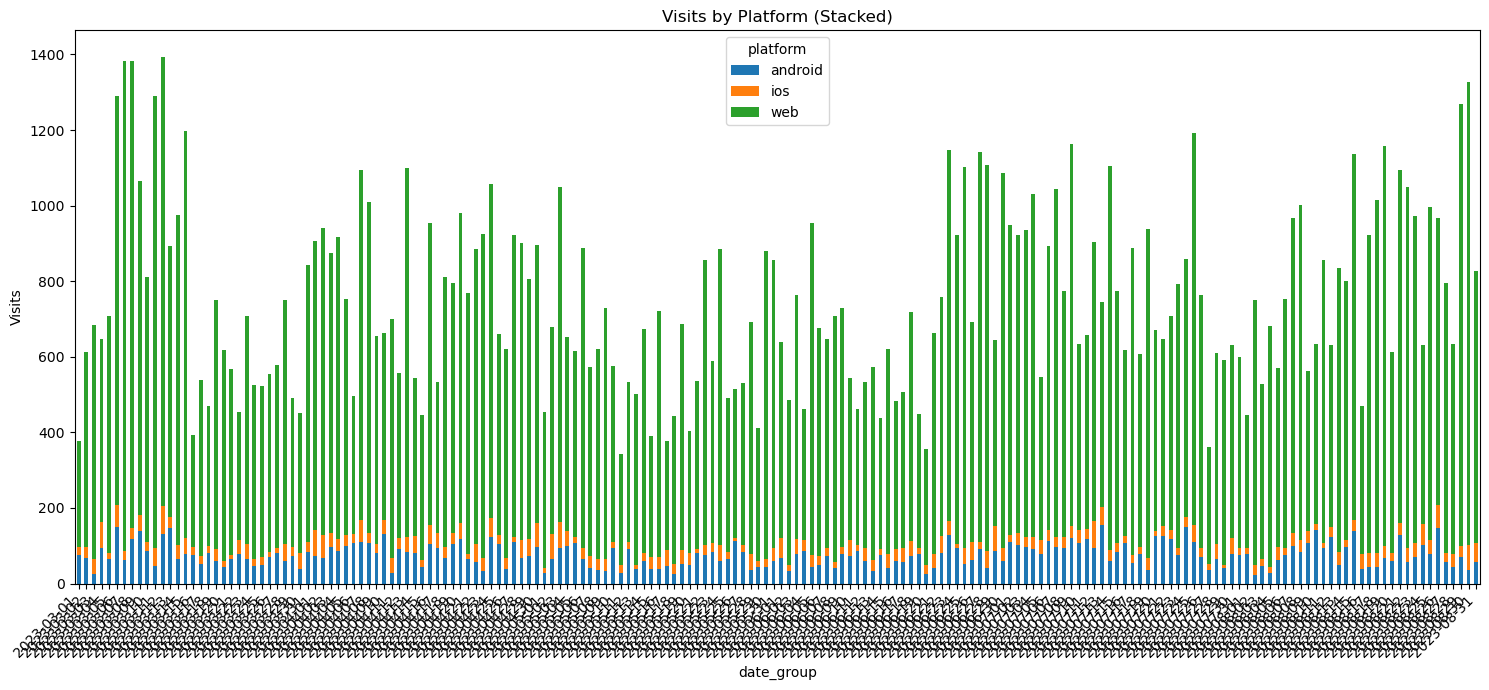

In [168]:
pivot.index = pivot.index.strftime("%Y-%m-%d")

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 7)
)

plt.title("Visits by Platform (Stacked)")
plt.xlabel("date_group")
plt.ylabel("Visits")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig('./charts/Visits by Platform (Stacked).png')

plt.show()

# Итоговые регистрации

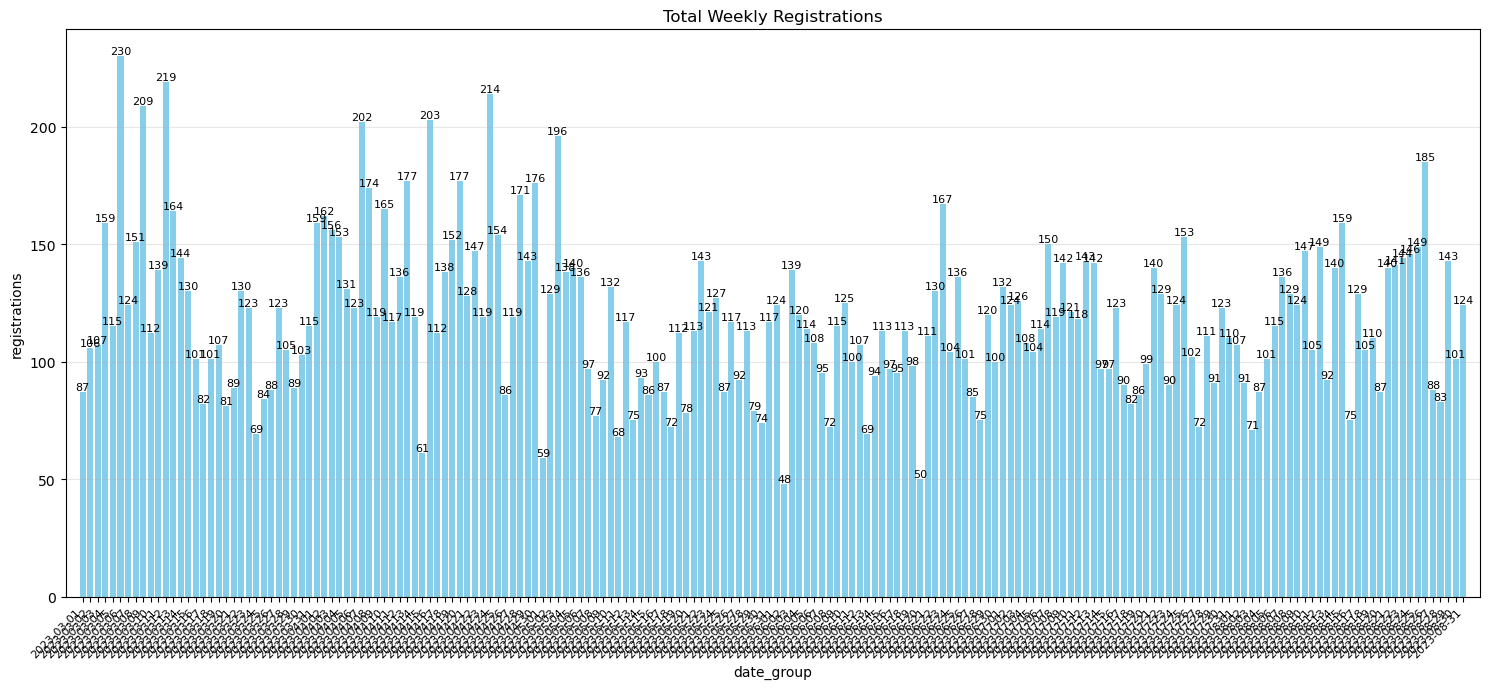

In [169]:
plt.figure(figsize=(15, 7))

bars = plt.bar(
    conversion_period["date_group"].dt.strftime("%Y-%m-%d"),
    conversion_period["registrations"],
    color="skyblue",
    width=0.8
)

plt.bar_label(bars, fontsize=8)
plt.title("Total Weekly Registrations")
plt.xlabel("date_group")
plt.ylabel("registrations")

plt.xticks(rotation=45, ha="right", fontsize=8)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.margins(x=0.01)

plt.savefig('./charts/Total Weekly Registrations.png')

plt.show()

# Итоговые регистрации с разбивкой по платформе

In [170]:
pivot = conversion_period_by_platforms.pivot(
    index="date_group",
    columns="platform",
    values="registrations")

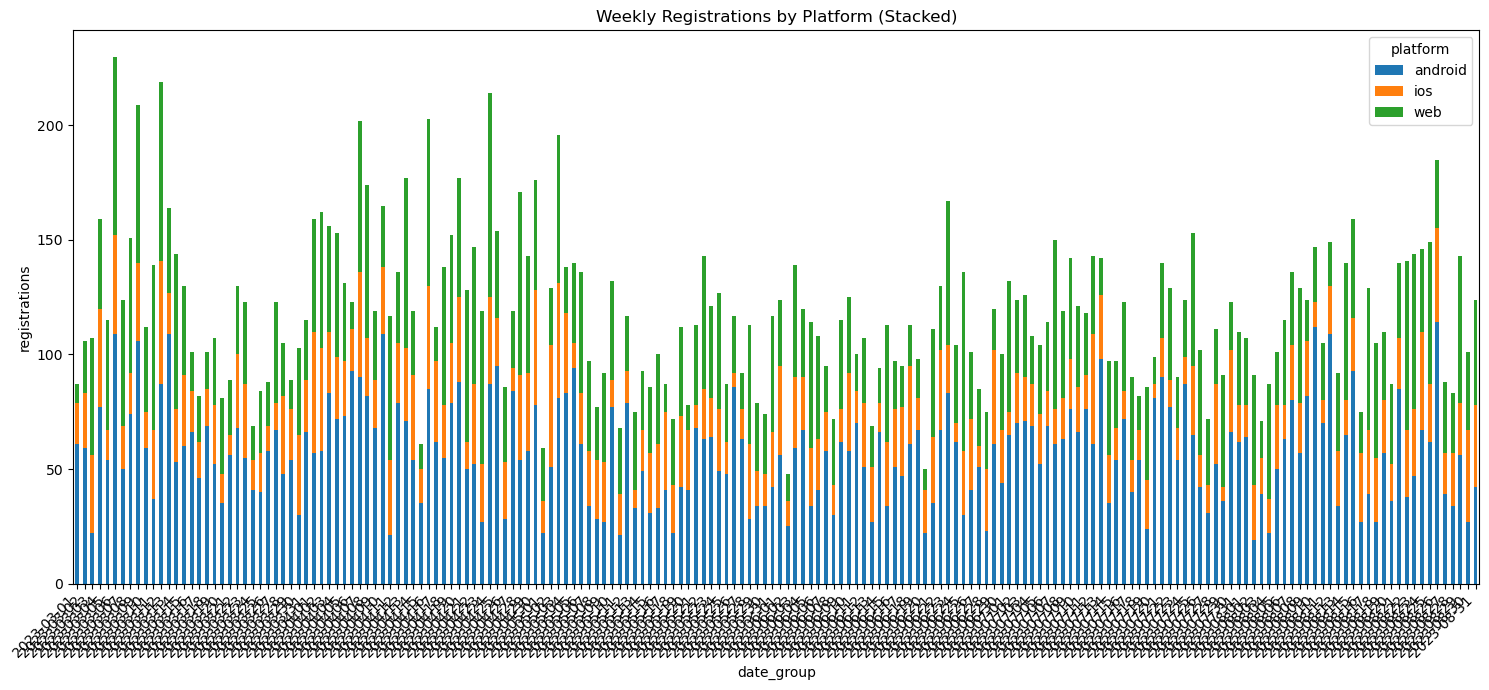

In [171]:
pivot.index = pivot.index.strftime("%Y-%m-%d")

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 7)
)

plt.title("Weekly Registrations by Platform (Stacked)")
plt.xlabel("date_group")
plt.ylabel("registrations")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig('./charts/Weekly Registrations by Platform (Stacked).png')

plt.show()

# Итоговые конверсии

In [172]:
conversion_grouped['conversion'] = (
    conversion_grouped['registrations'] /
    conversion_grouped['visits'] ) * 100

In [173]:
conversion_period = conversion_grouped[
    (conversion_grouped["date_group"] >= DATE_BEGIN) &
    (conversion_grouped["date_group"] < DATE_END)
]

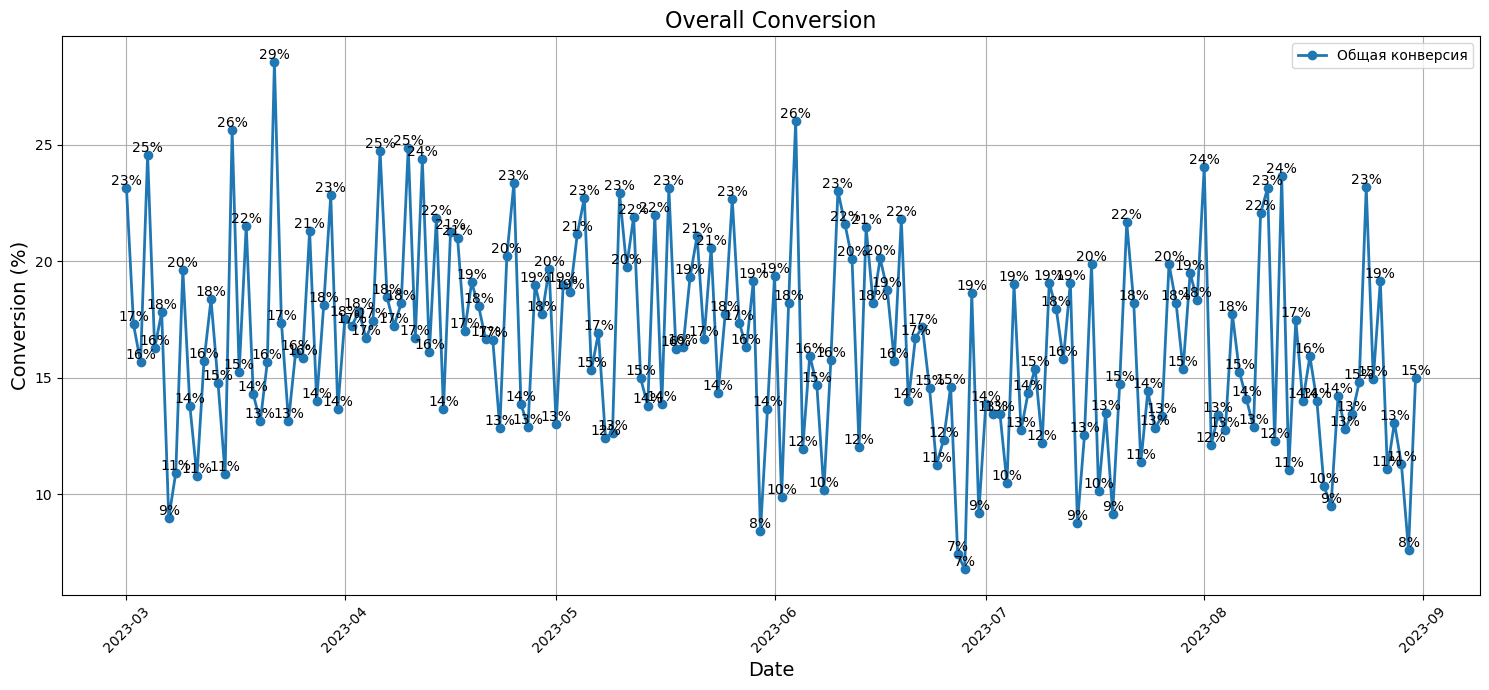

In [174]:
plt.figure(figsize=(15, 7))

plt.plot(
    conversion_period["date_group"],
    conversion_period["conversion"],
    marker="o",
    linewidth=2,
    label="Общая конверсия"
)

# Подписи над каждой точкой
for x, y in zip(
    conversion_period["date_group"],
    conversion_period["conversion"]
):
    plt.text(
        x,
        y,
        f"{y:.0f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Overall Conversion", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Conversion (%)", fontsize=14)

plt.xticks(rotation=45)
plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig('./charts/Overall Conversion.png')

plt.show()

# Конверсия по каждой платформе

In [175]:
conversion["date_group"] = pd.to_datetime(conversion["date_group"])
conversion_period_by_platforms = conversion[
    (conversion["date_group"] >= DATE_BEGIN) &
    (conversion["date_group"] < DATE_END)
]

In [176]:
conversion_period_by_platforms

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355
...,...,...,...,...,...
546,2023-08-30,android,35,27,77.142857
548,2023-08-30,web,1227,34,2.770986
550,2023-08-31,ios,50,36,72.000000
549,2023-08-31,android,57,42,73.684211


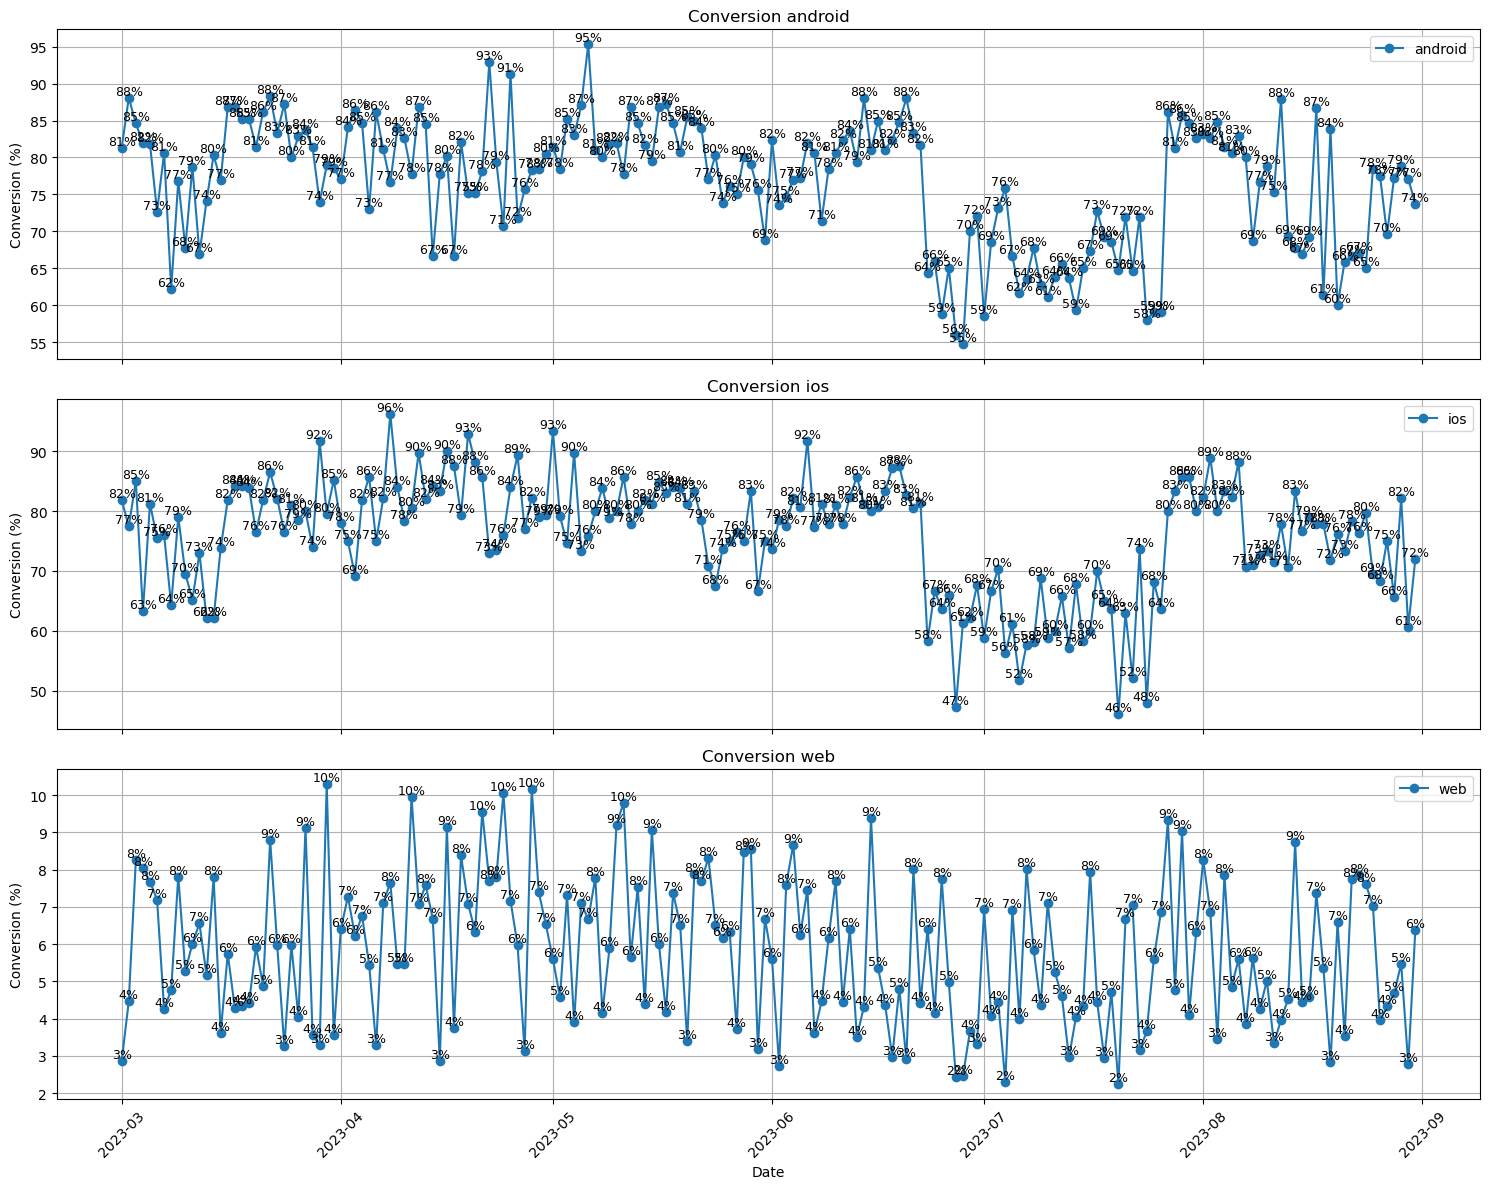

In [177]:
platforms = ["android", "ios", "web"]

fig, ax = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i, platform in enumerate(platforms):

    df = conversion_period_by_platforms[
        conversion_period_by_platforms["platform"] == platform
    ]

    ax[i].plot(
        df["date_group"],
        df["conversion"],
        marker="o",
        linewidth=1.5,
        label=platform
    )

    # Подписи над точками
    for x, y in zip(df["date_group"], df["conversion"]):
        ax[i].text(
            x,
            y,
            f"{y:.0f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax[i].set_title(f"Conversion {platform}")
    ax[i].set_ylabel("Conversion (%)")
    ax[i].grid(True)
    ax[i].legend()

ax[2].set_xlabel("Date")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('./charts/Conversion by platform.png')

plt.show()

# Стоимости реклам

In [178]:
ads_grouped["date_group"] = pd.to_datetime(ads_grouped["date_group"])

In [179]:
ads_period = ads_grouped[
    (ads_grouped["date_group"] >= DATE_BEGIN) &
    (ads_grouped["date_group"] < DATE_END)
]

In [180]:
ads_period.head()

,date_group,utm_campaign,cost
0,2023-03-01,advanced_algorithms_series,212
1,2023-03-02,advanced_algorithms_series,252
2,2023-03-03,advanced_algorithms_series,202
3,2023-03-04,advanced_algorithms_series,223
4,2023-03-05,advanced_algorithms_series,265


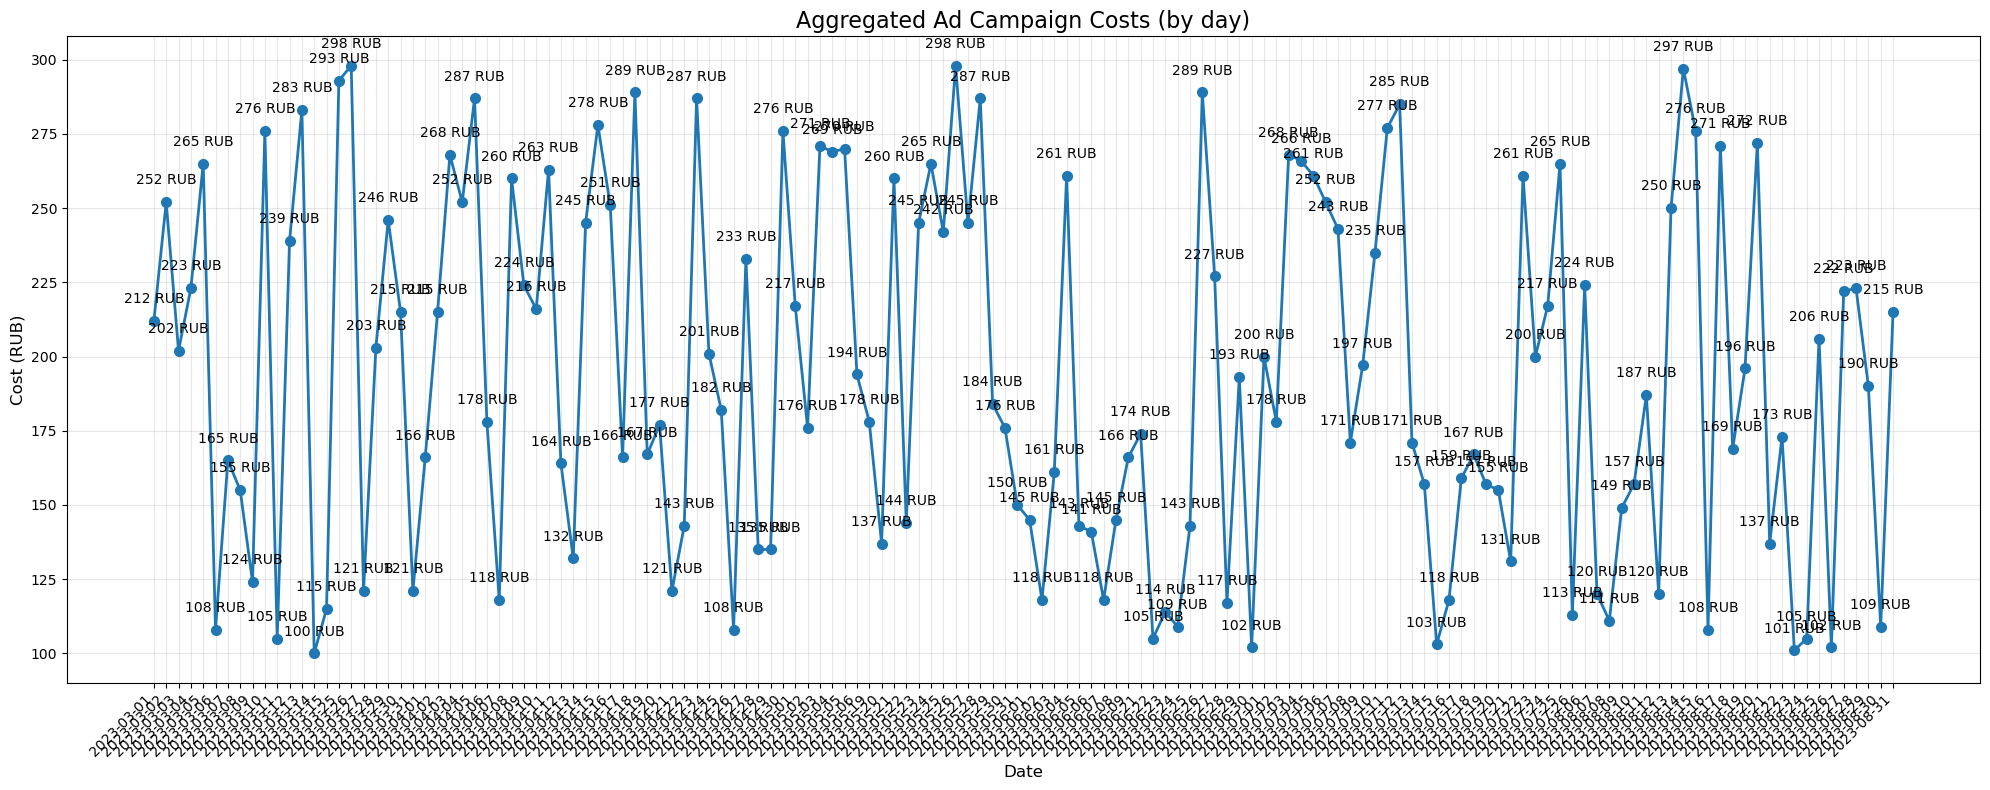

In [181]:
dates = ads_period["date_group"].dt.strftime("%Y-%m-%d")
costs = ads_period["cost"]

plt.figure(figsize=(20, 8))

# линия с точками
plt.plot(
    dates,
    costs,
    marker="o",
    linewidth=2,
    markersize=7
)

# подписи значений над точками
for x, y in zip(dates, costs):
    plt.text(
        x,
        y + 5,              # немного выше точки
        f"{y:.0f} RUB",
        ha="center",
        va="bottom",
        fontsize=10
    )

# заголовок
plt.title(
    "Aggregated Ad Campaign Costs (by day)",
    fontsize=16
)

# подписи осей
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cost (RUB)", fontsize=12)

# поворот дат
plt.xticks(
    rotation=45,
    ha="right"
)

# сетка
plt.grid(
    axis="both",
    alpha=0.3
)

# чтобы график не обрезался
plt.tight_layout()

plt.savefig('./charts/Aggregated Ad Campaign Costs (by day).png')

plt.show()

# Визиты и регистрации с выделением рекламных кампаний

In [182]:
ads.head()

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,212.0,advanced_algorithms_series
1,2023-03-02,613,106,252.0,advanced_algorithms_series
2,2023-03-03,683,107,202.0,advanced_algorithms_series
3,2023-03-04,647,159,223.0,advanced_algorithms_series
4,2023-03-05,707,115,265.0,advanced_algorithms_series


In [183]:
campaigns = (
    ads.groupby("utm_campaign")
    .agg(
        start_date=("date_group", "min"),
        end_date=("date_group", "max")
    )
    .reset_index())
campaigns

,utm_campaign,start_date,end_date
0,advanced_algorithms_series,2023-03-01,2023-03-15
1,intro_to_python_course,2023-08-06,2023-08-31
2,none,2023-03-16,2023-08-05
3,ui_ux_design_drive,2023-05-19,2023-06-09
4,virtual_reality_workshop,2023-03-25,2023-05-06
5,women_in_tech_symposium,2023-06-21,2023-07-26


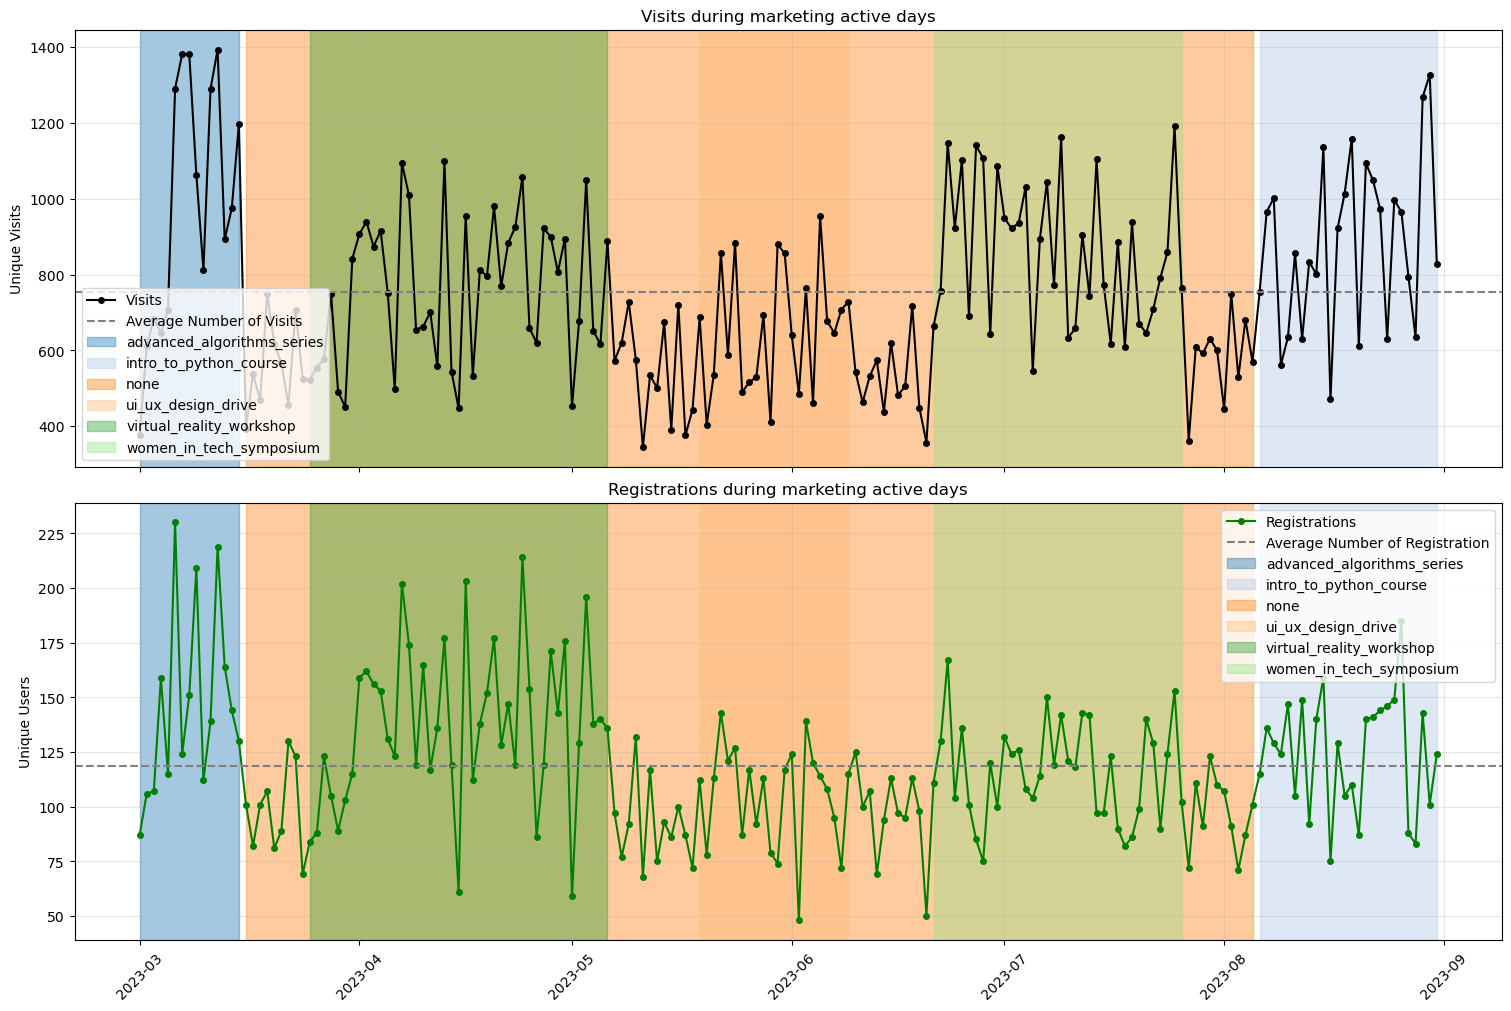

In [184]:
ads["date_group"] = pd.to_datetime(ads["date_group"])

# Средние значения
avg_visits = ads["visits"].mean()
avg_registrations = ads["registrations"].mean()

# Определяем периоды рекламных кампаний
campaigns = (
    ads.groupby("utm_campaign")
    .agg(
        start_date=("date_group", "min"),
        end_date=("date_group", "max")
    )
    .reset_index()
)

# Цвета для кампаний
colors = plt.cm.tab20.colors

# Создаем фигуру
fig, ax = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True,
    constrained_layout=True
)

# График — Visits

ax[0].plot(
    ads["date_group"],
    ads["visits"],
    color="black",
    marker="o",
    linewidth=1.5,
    markersize=4,
    label="Visits"
)

ax[0].axhline(
    avg_visits,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Average Number of Visits"
)

# Закрашиваем периоды кампаний
for color, (_, row) in zip(colors, campaigns.iterrows()):
    ax[0].axvspan(
        row["start_date"],
        row["end_date"],
        color=color,
        alpha=0.4,
        label=row["utm_campaign"]
    )

ax[0].set_title("Visits during marketing active days")
ax[0].set_ylabel("Unique Visits")
ax[0].grid(alpha=0.3)
ax[0].legend(loc="lower left")

# График — Registrations

ax[1].plot(
    ads["date_group"],
    ads["registrations"],
    color="green",
    marker="o",
    linewidth=1.5,
    markersize=4,
    label="Registrations"
)

ax[1].axhline(
    avg_registrations,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Average Number of Registration"
)

# Закрашиваем периоды кампаний
for color, (_, row) in zip(colors, campaigns.iterrows()):
    ax[1].axvspan(
        row["start_date"],
        row["end_date"],
        color=color,
        alpha=0.4,
        label=row["utm_campaign"]
    )

ax[1].set_title("Registrations during marketing active days")
ax[1].set_ylabel("Unique Users")
ax[1].grid(alpha=0.3)
ax[1].legend(loc="upper right")

# Форматирование оси X
plt.xticks(rotation=45)

plt.savefig('./charts/Visits and registrations with advertising campaigns highlighted.png')

plt.show()

In [185]:
import os

print(os.getcwd())

C:\Users\User\Desktop\Учеба\Проект 3\data-analytics-project-100


# Создать папку charts

In [186]:
import os

os.makedirs("charts", exist_ok=True)

In [187]:
%%writefile .env

API_URL=https://data-charts-api.hexlet.app
DATE_BEGIN=2023-03-01
DATE_END=2023-09-01

Overwriting .env


In [188]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("API_URL"))

https://data-charts-api.hexlet.app
